In [4]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create an empty list that will contain all the rows for the creation of the DataFrame
rows = []
# Iterates over all the files in the folder
for file in Path("data").rglob("*.json"):
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Iterates over each dictionary in the list results in the file
    for trial in data["resultats"]:
        # Doesn't take into account the first dictionnary in the list results
        if trial.get("task") != "target":
            continue
        # If no RT, we pass the dictionnary (no interest)
        rt = trial["rt"]
        if not rt:
            continue
        # Get the name of the stimulus
        stimulus=trial["stimulus"]
        if 'M' in stimulus:
            continue
        # Get the valence of the word
        valence_word = trial["valence"]
        # Get the label of the face ["Attractif","Unattractif"]
        label_face = trial["baseline_attrac"]
        # Get the id of the participant 
        participant_id = trial["participant_id"]
        # Get the response meaning ["Attractif","Non attractif"]
        response_meaning = trial["response_meaning"]
        # Indicates if the label of the face ["Attractif": +,"Non attractif": -] is congruent with the valence of the word
        if valence_word=='neutre':
            congruence='neutre'
        elif (valence_word== "positif" and label_face == "Attractif") or (valence_word == "negatif" and label_face == "Unattractif"):
            congruence = "congruent"
        else:
            congruence = "incongruent"
        # Indicates if the answer is correct or not
        if (label_face == "Attractif" and response_meaning == "Attractif") or (label_face == "Unattractif" and response_meaning == "Non attractif"):
            correct = 1
        else:
            correct = 0
        # Convert response meaning in binary
        if response_meaning=='Attractif':
            response_binary=1
        else:
            response_binary=0
        # Create the row for the DataFrame
        rows.append({
            "id": participant_id,
            "stimulus":stimulus,
            "valence_word":valence_word,
            "label_face":label_face, 
            "congruence": congruence,
            "response_meaning":response_meaning,
            "response_binary":response_binary,
            "correct": correct,
            "rt": rt/1000
        })

# Create the DataFrame
df = pd.DataFrame(rows)
# Display the DataFrame
df

,id,stimulus,valence_word,label_face,congruence,response_meaning,response_binary,correct,rt
0,1v24kyhs,face_attrac/LF-243.jpg,negatif,Attractif,incongruent,Attractif,1,1,0.975
1,1v24kyhs,face_attrac/BF-217.jpg,positif,Attractif,congruent,Attractif,1,1,1.308
2,1v24kyhs,face_attrac/LF-249.jpg,neutre,Attractif,neutre,Attractif,1,1,1.093
3,1v24kyhs,face_attrac/BF-240.jpg,negatif,Attractif,incongruent,Non attractif,0,0,1.345
4,1v24kyhs,face_attrac/WF-003.jpg,positif,Attractif,congruent,Attractif,1,1,1.221
...,...,...,...,...,...,...,...,...,...
1938,zzzboj5f,face_attrac/BF-241.jpg,negatif,Attractif,incongruent,Attractif,1,1,0.702
1939,zzzboj5f,face_unnattrac/WF-248.jpg,negatif,Unattractif,congruent,Non attractif,0,1,0.568
1940,zzzboj5f,face_attrac/AF-242.jpg,negatif,Attractif,incongruent,Attractif,1,1,0.533
1941,zzzboj5f,face_attrac/BF-217.jpg,negatif,Attractif,incongruent,Non attractif,0,0,0.643


# Remove outliers

In [5]:
# --- Identify accuracy outliers (<= 0%) ---
accuracy_by_id = df.groupby('id')['correct'].mean()
id_outliers_acc = accuracy_by_id[accuracy_by_id <= 0.50].index

# --- Compute rejection rate per stimulus ---
taux_rejet = (
    df.groupby('stimulus')['correct']
    .apply(lambda x: 1 - x.mean())  # proportion of incorrect responses
)

# --- Identify ambiguous stimuli (>33% rejection) ---
stimuli_ambigus = taux_rejet[taux_rejet > 0.330].index.tolist()

# --- Identify RT outliers ---
rt_by_id = df.groupby('id')['rt'].mean()
rt_threshold = df['rt'].mean() - df['rt'].std()
id_outliers_rt = rt_by_id[rt_by_id < rt_threshold].index

# --- Combine all participant outliers ---
id_outliers = id_outliers_acc.union(id_outliers_rt).union(pd.Index(['imgzntah']))

# --- Remove outliers + ambiguous stimuli ---
data_without_outliers = df[
    (~df['id'].isin(id_outliers)) & 
    (~df['stimulus'].isin(stimuli_ambigus))
]

# --- Summary stats per participant ---
dwo_display = (
    data_without_outliers
    .groupby('id')['correct']
    .mean()
    .reset_index(name='Percentage good answers')
)

# --- Global stats ---
print(f"Mean percentage of good answers: {dwo_display['Percentage good answers'].mean():.3f}")
print(f"Min percentage of good answers: {dwo_display['Percentage good answers'].min():.3f}")
print(f"Max percentage of good answers: {dwo_display['Percentage good answers'].max():.3f}")

display(dwo_display)

Mean percentage of good answers: 0.839
Min percentage of good answers: 0.607
Max percentage of good answers: 1.000


,id,Percentage good answers
0,1v24kyhs,0.888889
1,2jp4ppt2,0.724138
2,3ofn5wde,0.964286
3,4hgpolkf,0.821429
4,66o3mn1h,0.851852
5,6ipwu4mk,0.750000
6,71f898fp,0.758621
7,7eih1i0q,0.620690
8,7re7u25l,0.827586
9,7rngwvq4,1.000000


In [6]:
for label in ["Attractif","Unattractif"]:
    for val in ["positif","neutre","negatif"]:
        print(f"For {label} face preceded by a {val} word, the mean rt is: {data_without_outliers[(data_without_outliers['label_face']==label)&(data_without_outliers['valence_word']==val)]['rt'].mean()}")

For Attractif face preceded by a positif word, the mean rt is: 0.7920531914893617
For Attractif face preceded by a neutre word, the mean rt is: 0.8030091743119265
For Attractif face preceded by a negatif word, the mean rt is: 0.8045308056872037
For Unattractif face preceded by a positif word, the mean rt is: 0.7514273127753305
For Unattractif face preceded by a neutre word, the mean rt is: 0.754280612244898
For Unattractif face preceded by a negatif word, the mean rt is: 0.7360627802690582


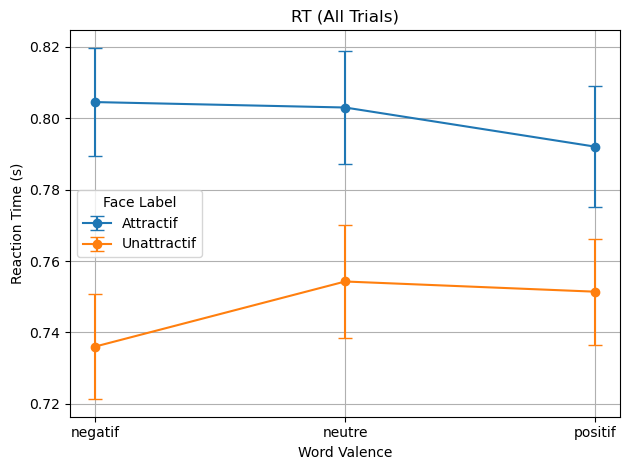

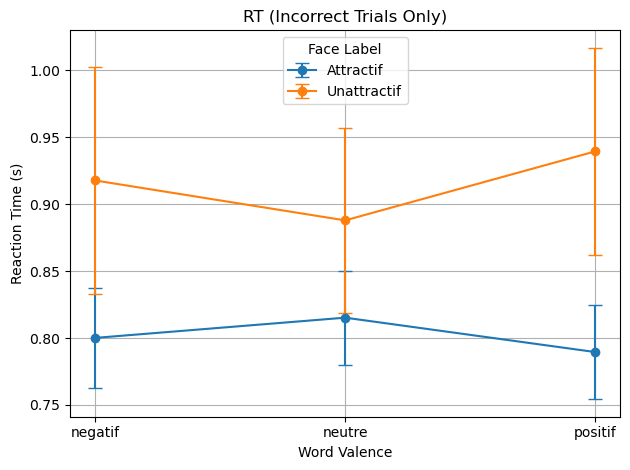

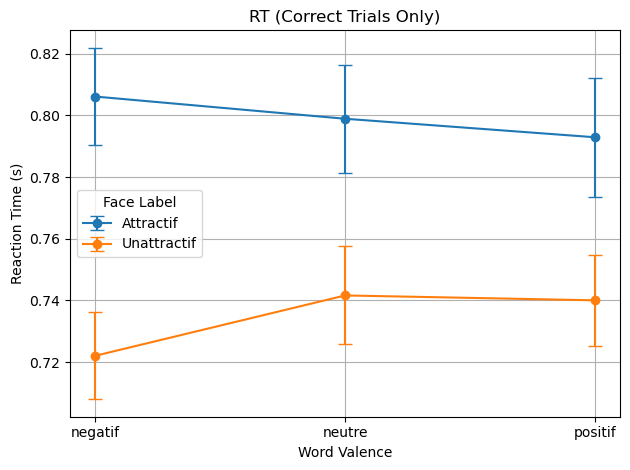

In [7]:
def plot_rt(data, title):
    # --- Prepare summary data ---
    summary = (
        data
        .groupby(['label_face', 'valence_word'])['rt']
        .agg(
            mean='mean',
            sem=lambda x: x.std() / np.sqrt(len(x))
        )
        .reset_index()
    )

    # Ensure correct order
    order = ['negatif', 'neutre', 'positif']
    summary['valence_word'] = pd.Categorical(summary['valence_word'], categories=order, ordered=True)
    summary = summary.sort_values('valence_word')

    # --- Plot ---
    plt.figure()

    for label in summary['label_face'].unique():
        subset = summary[summary['label_face'] == label]

        plt.errorbar(
            subset['valence_word'],
            subset['mean'],
            yerr=subset['sem'],
            marker='o',
            capsize=5,
            label=label
        )

    plt.xlabel("Word Valence")
    plt.ylabel("Reaction Time (s)")
    plt.title(title)
    plt.legend(title="Face Label")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# --- 1. All trials ---
plot_rt(data_without_outliers, "RT (All Trials)")

# --- 2. Incorrect only ---
plot_rt(
    data_without_outliers[data_without_outliers['correct'] == 0],
    "RT (Incorrect Trials Only)"
)

# --- 3. Correct only ---
plot_rt(
    data_without_outliers[data_without_outliers['correct'] == 1],
    "RT (Correct Trials Only)"
)